Loan Prediction Model
January 2025 - Present
I developed a machine learning solution to predict loan approval outcomes using applicant financial data. By implementing and evaluating classification algorithms like including Logistic Regression, Decision Trees, and Random Forests, I built and compared multiple models to identify the most effective approach for accurate and reliable prediction.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
data = pd.read_csv("LoanData.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Data Understanding**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
data["Loan_ID"].nunique()

614

**Drop unimportant columns as per feature selection (Filter methods)**

In [ ]:
data.drop(columns=["Loan_ID"],inplace=True)

In [ ]:
data["Gender"].unique()

array(['Male', 'Female', nan], dtype=object)

In [ ]:
data["Gender"].value_counts()

,count
Gender,
Male,489
Female,112


In [ ]:
data["Married"].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
data["Married"].value_counts()

,count
Married,
Yes,398
No,213


In [ ]:
data["Dependents"].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [ ]:
data["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [ ]:
data["Education"].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [ ]:
data["Education"].value_counts()

,count
Education,
Graduate,480
Not Graduate,134


In [ ]:
data["Self_Employed"].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
data["Self_Employed"].value_counts()

,count
Self_Employed,
No,500
Yes,82


**Create new columns as per requirements**

In [ ]:
data["Income"]=data["ApplicantIncome"] + data["CoapplicantIncome"]

data.drop(columns=["ApplicantIncome","CoapplicantIncome"],inplace=True)

In [ ]:
data["Loan_Amount_Term"].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [ ]:
data["Loan_Amount_Term"].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [ ]:
data["Credit_History"].unique()

array([ 1.,  0., nan])

In [ ]:
data["Credit_History"].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [ ]:
data["Property_Area"].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [ ]:
data["Property_Area"].value_counts()

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


In [ ]:
data["Loan_Status"].unique()

array(['Y', 'N'], dtype=object)

In [ ]:
data["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


In [ ]:
continuous = ['Income','LoanAmount']

discrete_categorical = ['Gender','Married','Education','Self_Employed','Credit_History','Property_Area','Loan_Status']

discrete_count =  ['Dependents','Loan_Amount_Term']

In [ ]:
data.dtypes

,0
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64
Property_Area,object
Loan_Status,object


**Exploratory Data Analysis (EDA)**

**For continuous variables**

In [ ]:
data[continuous].describe()

,Income,LoanAmount
count,614.000000,592.000000
mean,7024.705081,146.412162
std,6458.663872,85.587325
min,1442.000000,9.000000
25%,4166.000000,100.000000
50%,5416.500000,128.000000
75%,7521.750000,168.000000
max,81000.000000,700.000000


In [ ]:
data[continuous].skew()

,0
Income,5.633449
LoanAmount,2.677552


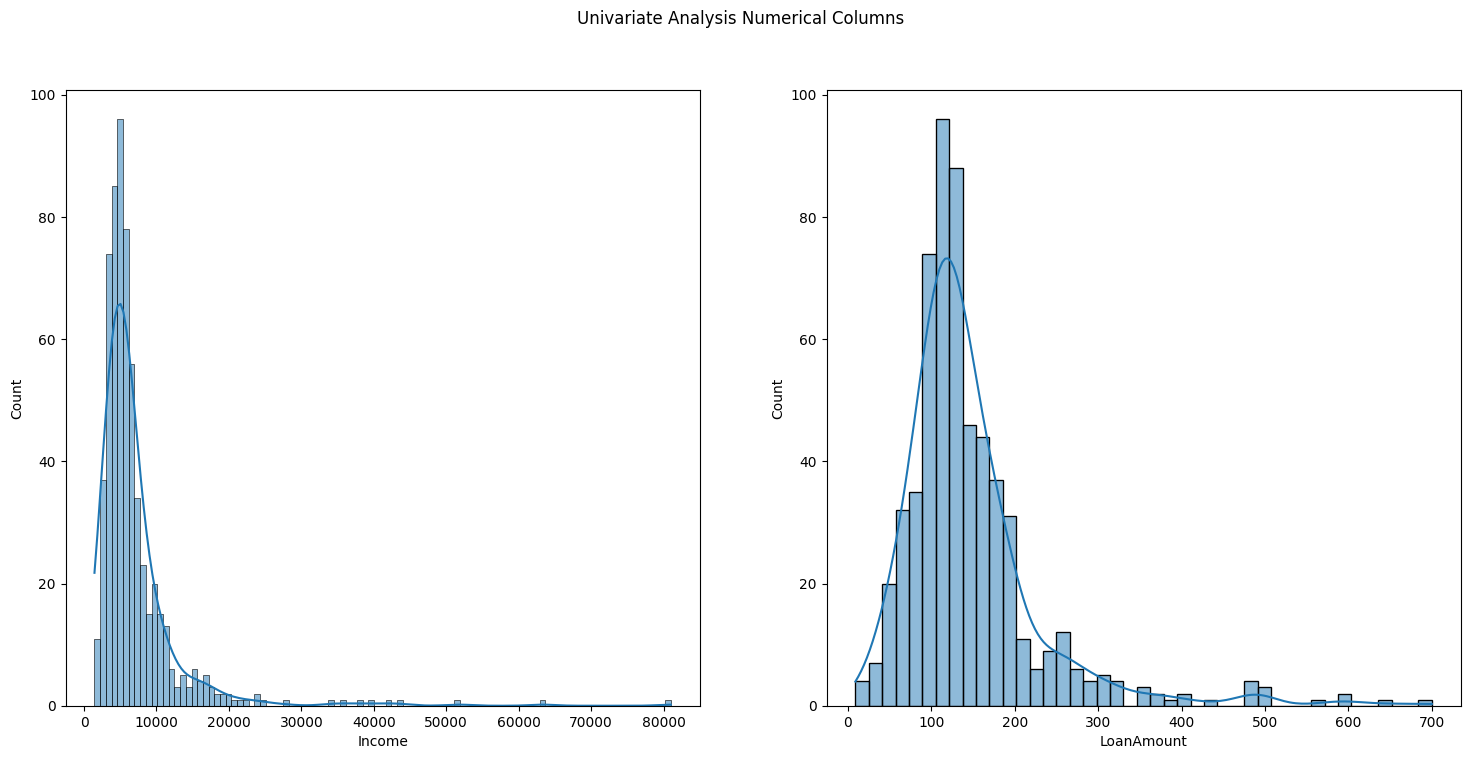

In [ ]:
plt.rcParams['figure.figsize'] = (18,8)

plt.subplot(1,2, 1)
sns.histplot(data[ 'Income'], kde=True)

plt.subplot(1,2, 2)
sns.histplot(data['LoanAmount'],kde=True)

plt.suptitle('Univariate Analysis Numerical Columns')
plt.show()

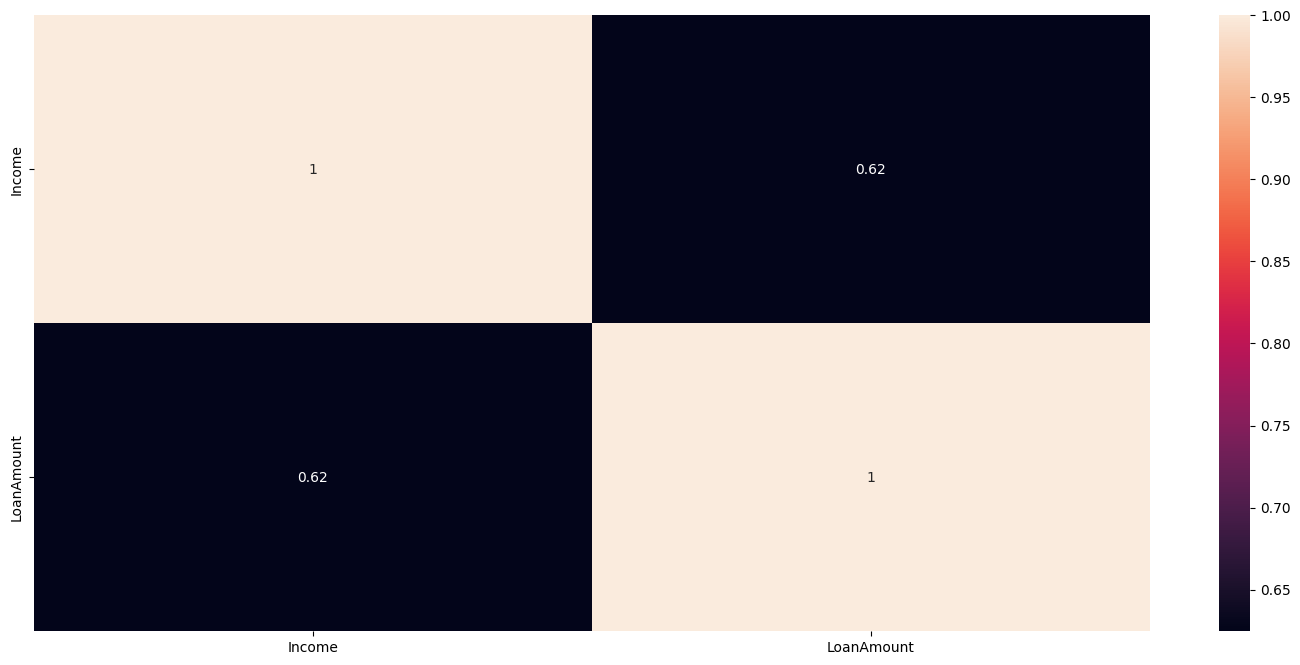

In [ ]:
sns.heatmap(data[continuous].corr(),annot=True)
plt.show()

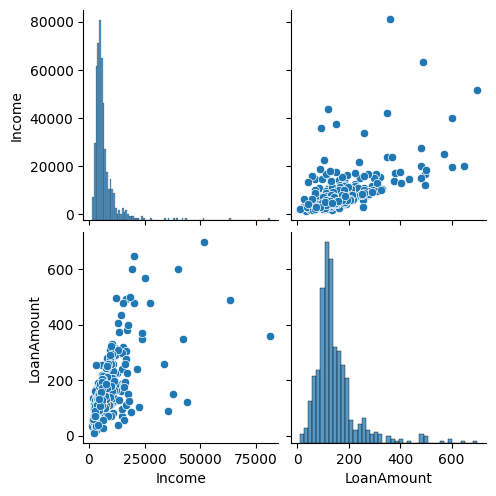

In [ ]:
sns.pairplot(data[continuous])
plt.show()


**For discrete variables**

In [ ]:
data[discrete_categorical].describe()

,Credit_History
count,564.000000
mean,0.842199
std,0.364878
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


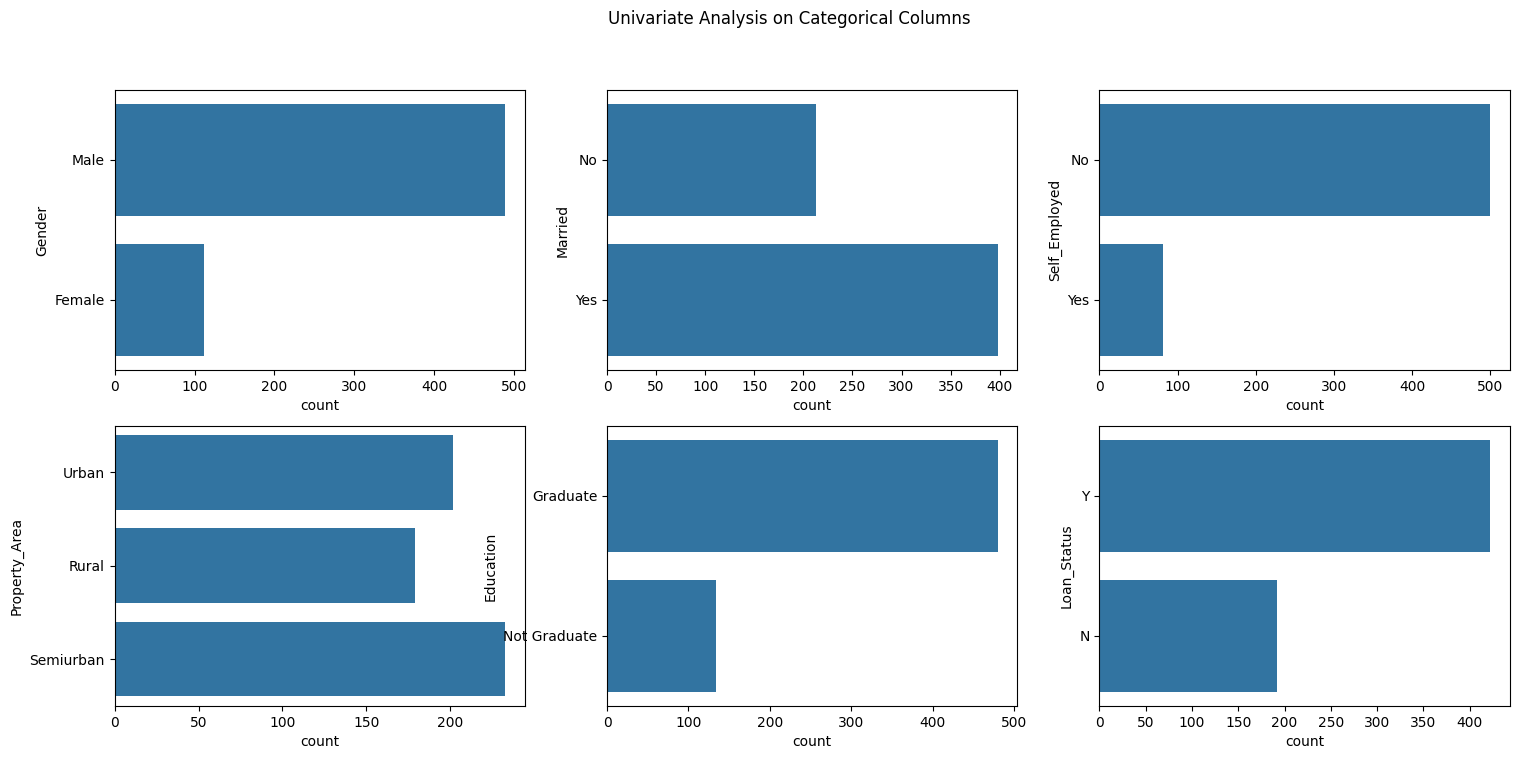

In [ ]:
plt.rcParams['figure.figsize'] = (18,8)

plt.subplot(2, 3, 1)
sns.countplot(data['Gender'])

plt.subplot(2, 3, 2)
sns.countplot(data['Married'])

plt.subplot(2, 3, 3)
sns.countplot(data['Self_Employed'])

plt.subplot(2, 3, 4)
sns.countplot(data['Property_Area'])

plt.subplot(2, 3, 5)
sns.countplot(data['Education'])

plt.subplot(2, 3, 6)
sns.countplot(data['Loan_Status'])

plt.suptitle('Univariate Analysis on Categorical Columns')
plt.show()


In [ ]:
# Lets compare all the Categories with respect to the Loan Status to understand the Overa

print("Impact of Marriage on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Married']))
print('\n')

print("Impact of Dependents on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Dependents']))
print('\n')

print("Impact of Education on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Education']))
print('\n')

print("Impact of Employment on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Self_Employed']))
print('\n')

# Lets compare all the Categories with respect to the Loan Status to understand the Overa

print("Impact of Marriage on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Married']))
print('\n')

print("Impact of Dependents on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Dependents']))
print('\n')

print("Impact of Education on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Education']))
print('\n')

print("Impact of Employment on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Self_Employed']))
print('\n')

print("Impact of Property on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Property_Area']))
print('\n')

print("Impact of Property on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Credit_History']))
print('\n')


Impact of Marriage on Loan Status
Married       No  Yes
Loan_Status          
N             79  113
Y            134  285


Impact of Dependents on Loan Status
Dependents     0   1   2  3+
Loan_Status                 
N            107  36  25  18
Y            238  66  76  33


Impact of Education on Loan Status
Education    Graduate  Not Graduate
Loan_Status                        
N                 140            52
Y                 340            82


Impact of Employment on Loan Status
Self_Employed   No  Yes
Loan_Status            
N              157   26
Y              343   56


Impact of Marriage on Loan Status
Married       No  Yes
Loan_Status          
N             79  113
Y            134  285


Impact of Dependents on Loan Status
Dependents     0   1   2  3+
Loan_Status                 
N            107  36  25  18
Y            238  66  76  33


Impact of Education on Loan Status
Education    Graduate  Not Graduate
Loan_Status                        
N                 140 

**check for missing values**

In [ ]:
data.isnull().sum()


,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50
Property_Area,0
Loan_Status,0


**check for skewness**

In [ ]:
data[continuous].skew()

,0
Income,5.633449
LoanAmount,2.677552


**check outliers**

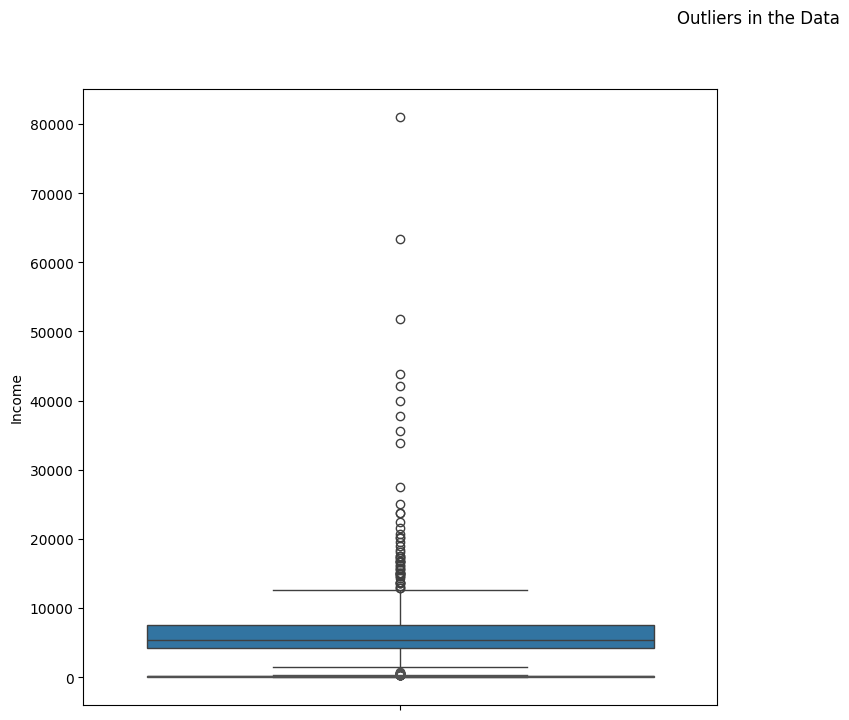

In [ ]:
plt.subplot(1, 2, 1)
sns.boxplot(data['Income'])

plt.subplot(1, 2, 1)
sns.boxplot(data['LoanAmount'])

plt.suptitle('Outliers in the Data')
plt.show()

**DATA PREPARATION**

**Wrong Data Treatment**

In [ ]:
data['Dependents'] = data['Dependents'].replace({'3+':3})

**Missing Value Treatment**

In [ ]:
data['Dependents'] = data['Dependents'].fillna(0)

data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

data = data.dropna(subset=['Income','LoanAmount','Loan_Amount_Term','Credit_History'])

**Data Type Conversion**

In [ ]:
data['Dependents'] = data['Dependents'].astype(int)
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype(int)


<ipython-input-41-613d24cd0bf9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Dependents'] = data['Dependents'].astype(int)
<ipython-input-41-613d24cd0bf9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype(int)


**Encoding**

In [ ]:
data['Gender'] = data['Gender'].replace({'Male':1, 'Female':0})
data['Married'] = data['Married'].replace({'Yes':1, 'No':0})
data['Education'] = data['Education'].replace({'Graduate':1, 'Not Graduate':0})
data['Self_Employed'] = data['Self_Employed'].replace({'Yes':1, 'No':0})
data['Property_Area'] = data['Property_Area'].replace({'Rural':0, 'Semiurban':1, 'Urban':2})
data['Credit_History'] = data['Credit_History'].replace({'good':1, 'bad':0})
data['Loan_Status'] = data['Loan_Status'].replace({'Y':1, 'N':0})


<ipython-input-42-66346fe36a14>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Gender'] = data['Gender'].replace({'Male':1, 'Female':0})
<ipython-input-42-66346fe36a14>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Gender'] = data['Gender'].replace({'Male':1, 'Female':0})
<ipython-input-42-66346fe36a14>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to th

In [ ]:
# transformations
from scipy.stats import boxcox
data['Income'], a = boxcox(data['Income'])
data['LoanAmount'], c = boxcox(data['LoanAmount'])

data['Loan_Amount_Term'] = data['Loan_Amount_Term'] / 12


**Splitting the data into X(Target) and y(Features)**

In [ ]:
X = data.drop('Loan_Status',axis=1)
y = data['Loan_Status']

**Train-Test-Split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**MODELLING AND EVALUATION**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score


**1. Logistic Regression**

In [ ]:
# Modelling
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predict & Evaluate on train data
ypred_train = log_model.predict(X_train)  # default threshold value is 0.5
print("Train Accuracy :", accuracy_score(y_train, ypred_train))

# Cross Validation on Train data
print("CV Score :", cross_val_score(log_model, X_train, y_train, cv=5, scoring="accuracy").mean())

# Predict & Evaluation on test data
ypred_test = log_model.predict(X_test)
print("Test Accuracy :", accuracy_score(y_test, ypred_test))


# Confusion matrix and classification report
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, ypred_test))

from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_test))


Train Accuracy : 0.8108747044917257
CV Score : 0.8109243697478992
Test Accuracy : 0.8301886792452831
[[16 17]
 [ 1 72]]
              precision    recall  f1-score   support

           0       0.94      0.48      0.64        33
           1       0.81      0.99      0.89        73

    accuracy                           0.83       106
   macro avg       0.88      0.74      0.76       106
weighted avg       0.85      0.83      0.81       106



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

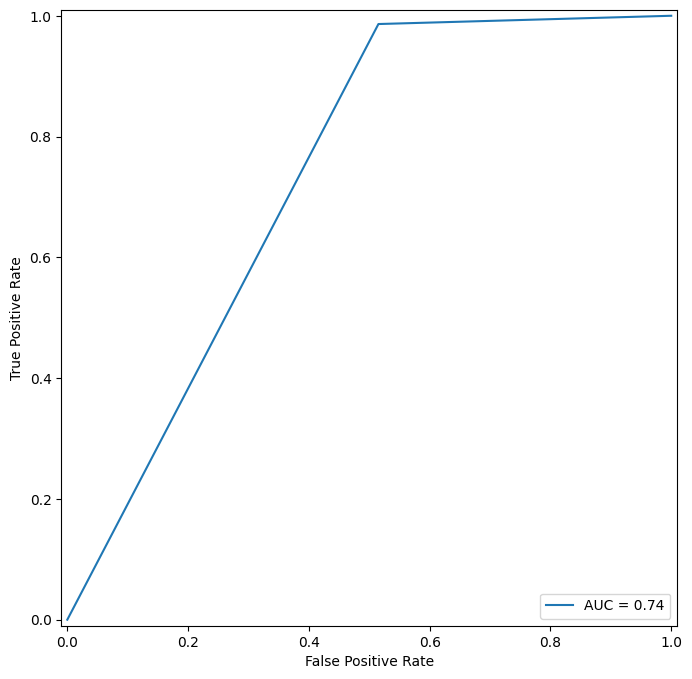

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

fpr, tpr, thresholds = roc_curve(y_test, ypred_test)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.show()


In [ ]:
#AUC score
from sklearn.metrics import roc_auc_score
print("AUC Score:",roc_auc_score(y_test,ypred_test))

AUC Score: 0.7355749273557493


**KNN**

In [ ]:
# Hyperparameter tuning
estimator = KNeighborsClassifier()
param_grid = {'n_neighbors': list(range(1,50)), "p":[1,2]}
knn_grid = GridSearchCV(estimator, param_grid, scoring='accuracy', cv=5)
knn_grid.fit(X_train, y_train)

# KNN with best Hyperparameters
knn_grid.best_estimator_


KNeighborsClassifier(n_neighbors=6, p=1)

In [ ]:
# Modelling
knn_model = knn_grid.best_estimator_
knn_model.fit(X_train, y_train)

# Predict & Evaluate on train data
ypred_train = knn_model.predict(X_train)
print("Train Accuracy :", accuracy_score(y_train, ypred_train))

# Cross Validation on Train data
print("CV Score :", cross_val_score(knn_model, X_train, y_train, cv=5, scoring="accuracy").mean())

# Predict & Evaluate on test data
ypred_test = knn_model.predict(X_test)
print("Test Accuracy :", accuracy_score(y_test, ypred_test))

Train Accuracy : 0.817966903073286
CV Score : 0.7613725490196078
Test Accuracy : 0.7358490566037735


**3.Support Vector Machine(SVM)**

In [ ]:
# Hyperparameter tuning
from sklearn.svm import SVC
estimator = SVC()
param_grid = {'C':[0.01,0.1,1],'kernel':['linear','rbf','sigmoid','poly']}
svm_grid = GridSearchCV(estimator, param_grid, scoring='accuracy', cv=5)
svm_grid.fit(X_train, y_train)

# SVM with best Hyperparameters
svm_grid.best_estimator_


SVC(C=0.1, kernel='linear')

In [ ]:
# Modelling
svm_model = svm_grid.best_estimator_
svm_model.fit(X_train, y_train)

# Predict & Evaluate on train data
ypred_train = svm_model.predict(X_train)
print("Train Accuracy :", accuracy_score(y_train, ypred_train))

# Cross Validation on Train data
print("CV Score :", cross_val_score(svm_model, X_train, y_train, cv=5, scoring="accuracy").mean())

# Predict & Evaluate on test data
ypred_test = svm_model.predict(X_test)
print("Test Accuracy :", accuracy_score(y_test, ypred_test))

Train Accuracy : 0.8108747044917257
CV Score : 0.8109243697478992
Test Accuracy : 0.8301886792452831


**Decision Tree Classifier**

**First create default DT model(fully grown tree without any pruning)** so that we can understand the max_depth

In [ ]:
model = DecisionTreeClassifier(random_state=True)
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=True)

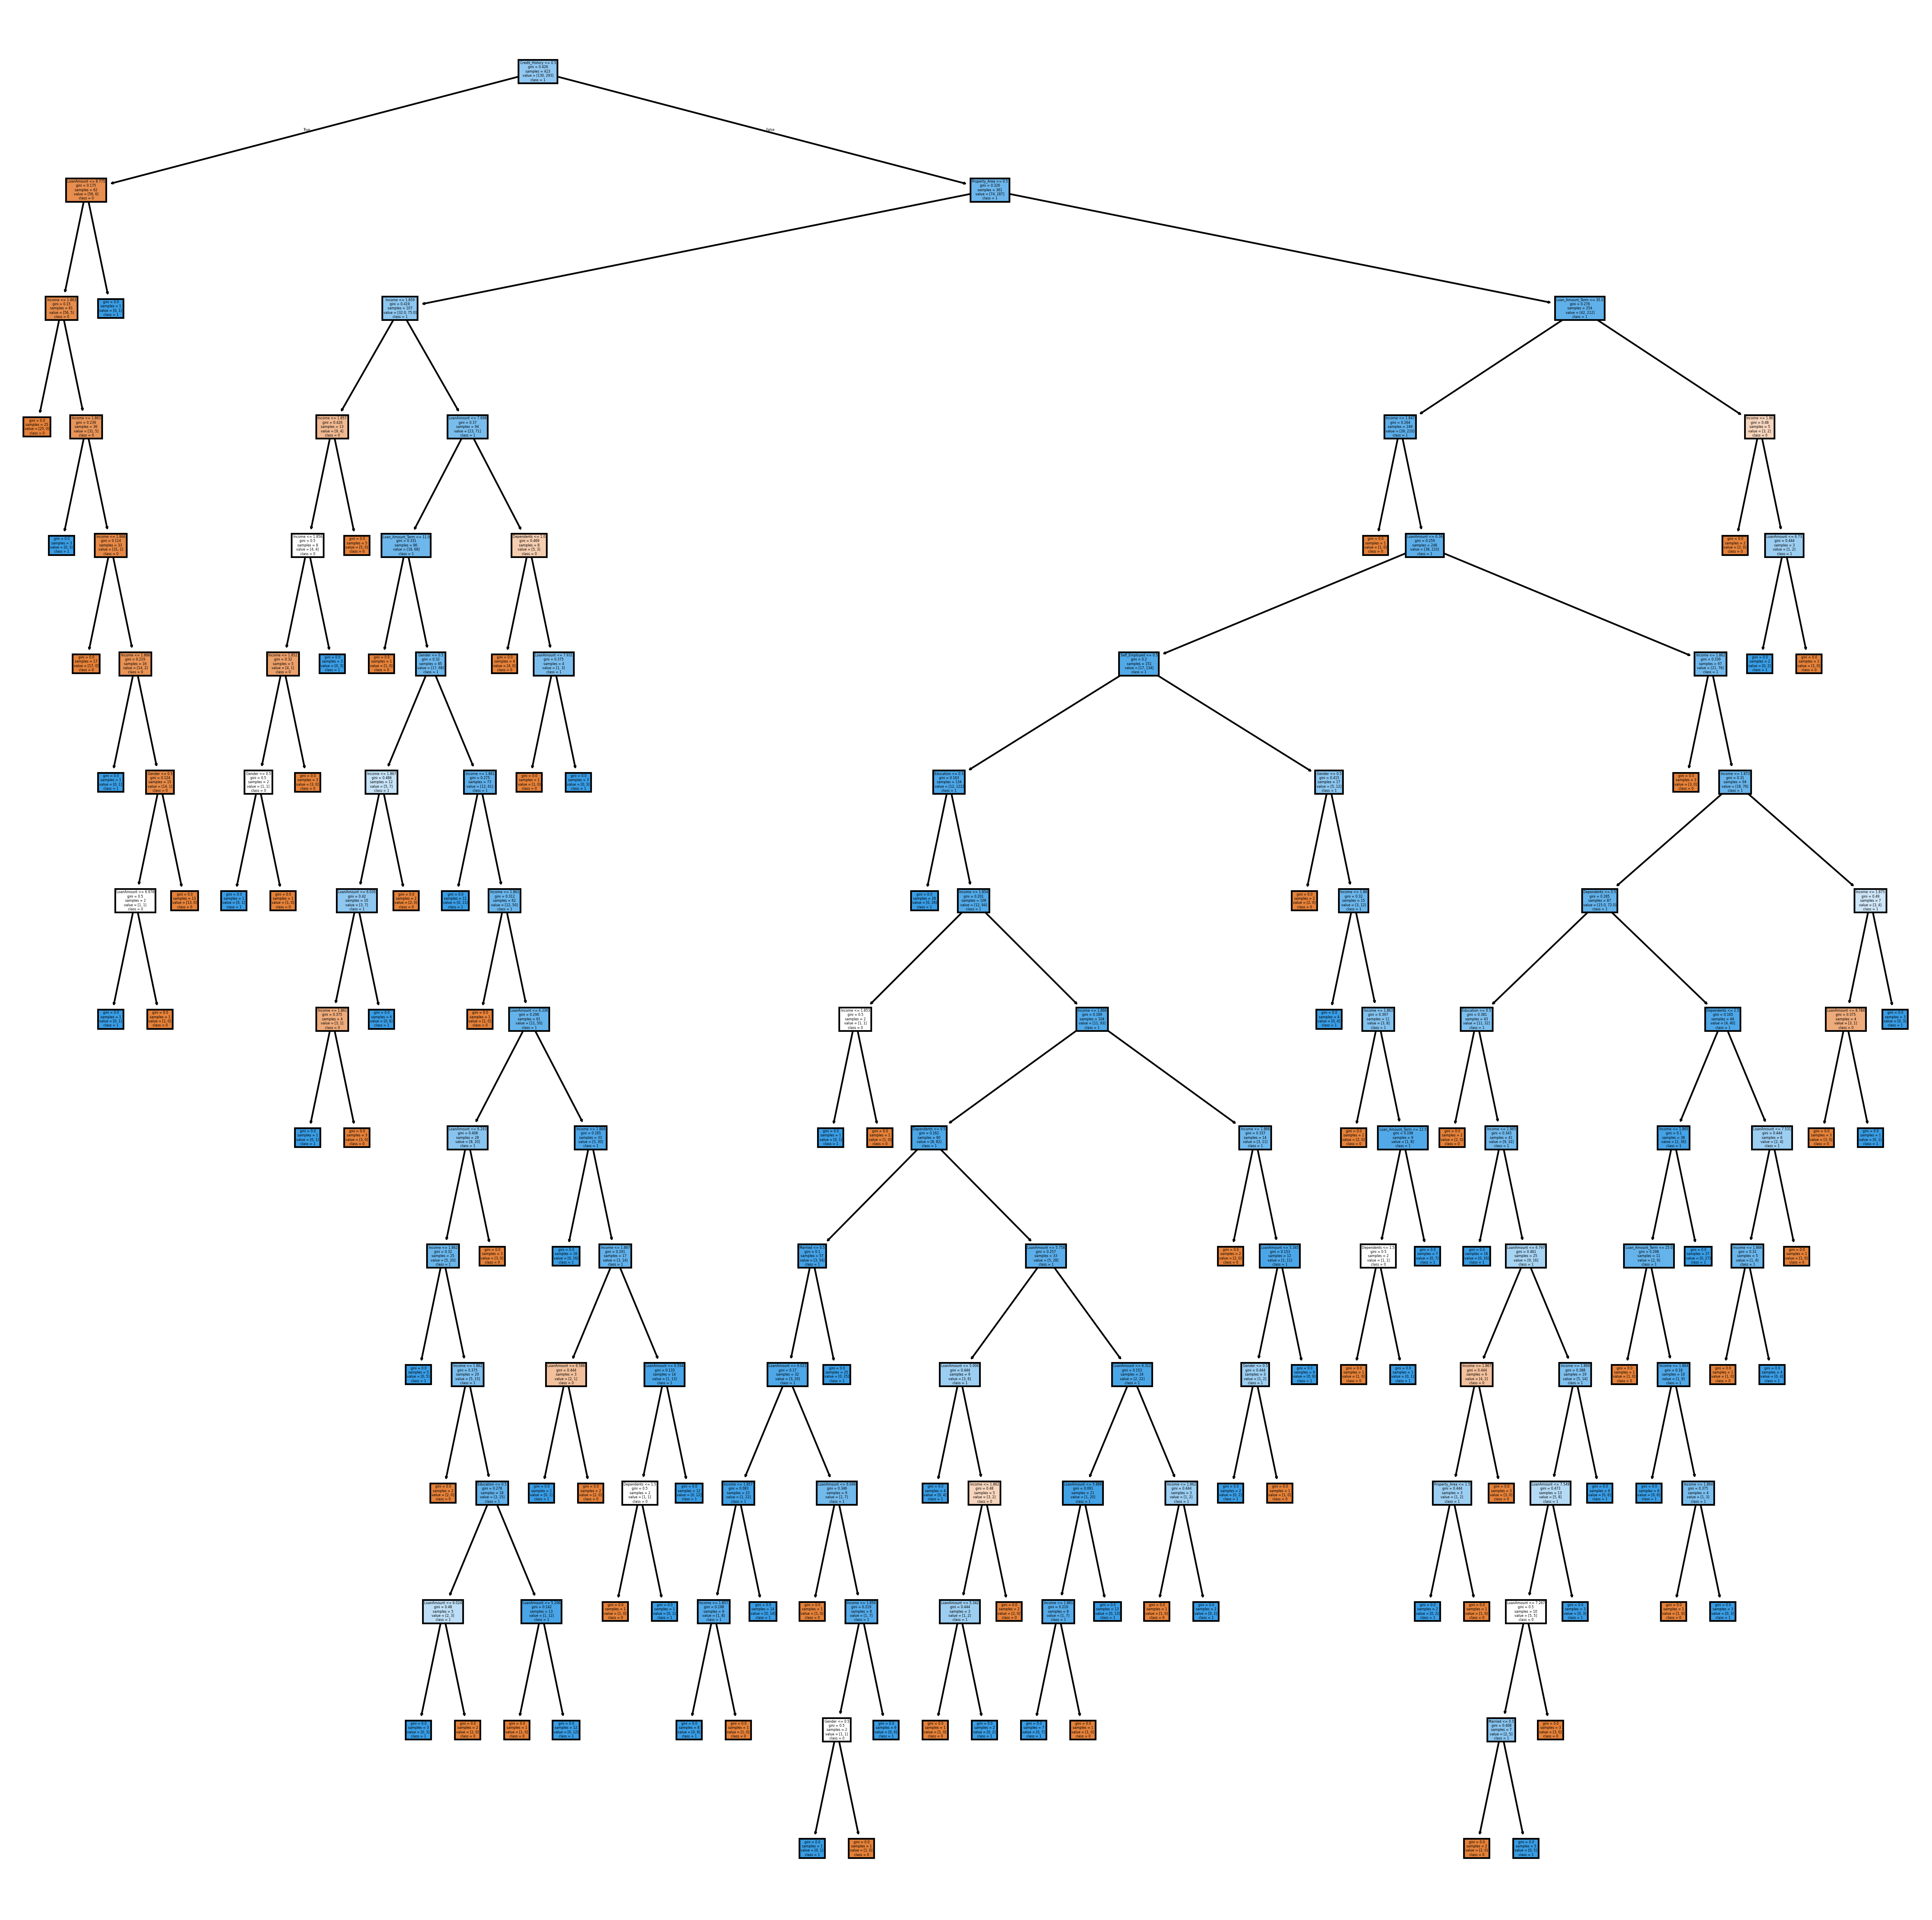

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20), dpi=300)
plot_tree(model, filled=True,
          feature_names=X_train.columns.tolist(),
          class_names=["0","1"])
plt.show()


In [ ]:
# Hyper parameter tuning
estimator = DecisionTreeClassifier(random_state=True)

param_grid = {"criterion":["gini", "entropy"],
              "max_depth":list(range(1,16))}

dt_grid = GridSearchCV(estimator, param_grid, scoring='accuracy', cv=5)
dt_grid.fit(X_train, y_train)

dt = dt_grid.best_estimator_
dt


DecisionTreeClassifier(max_depth=1, random_state=True)

In [ ]:
# Important features
feats_ab = pd.DataFrame(data=dt.feature_importances_,
                        index=X.columns,
                        columns=['Importance'])

important_features_dt = feats_ab[feats_ab["Importance"] > 0].index.tolist()
important_features_dt

['Credit_History']

**Creating Decision Tree Model with important parameters and important features**

In [ ]:

# Selecting train & test data
X_train_dt = X_train[important_features_dt]
X_test_dt = X_test[important_features_dt]

# Modelling
dt = dt_grid.best_estimator_
dt.fit(X_train_dt, y_train)

# Evaluation
ypred_train = dt.predict(X_train_dt)
ypred_test = dt.predict(X_test_dt)

print("Train Accuracy :", accuracy_score(y_train, ypred_train))
print("CV Score :", cross_val_score(dt, X_train_dt, y_train, cv=5, scoring="accuracy").mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))


Train Accuracy : 0.8108747044917257
CV Score : 0.8109243697478992
Test Accuracy : 0.8301886792452831


**5. Random Forest Classifier**

In [ ]:
# Hyper parameter tuning
estimator = RandomForestClassifier(random_state=True)

param_grid = {'n_estimators': list(range(1, 51))}

rf_grid = GridSearchCV(estimator, param_grid, scoring="accuracy", cv=5)
rf_grid.fit(X_train, y_train)

rf = rf_grid.best_estimator_
rf


RandomForestClassifier(n_estimators=39, random_state=True)

In [ ]:
# Important features
feats_ab = pd.DataFrame(data=rf.feature_importances_,
                        index=X.columns,
                        columns=['Importance'])

important_features_rf = feats_ab[feats_ab["Importance"] > 0].index.tolist()
important_features_rf


['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Income']

In [ ]:
X_train_rf = X_train[important_features_rf]
X_test_rf = X_test[important_features_rf]

# Modelling
rf = rf_grid.best_estimator_
rf.fit(X_train_rf, y_train)

# Evaluation
ypred_train = rf.predict(X_train_rf)
ypred_test = rf.predict(X_test_rf)

print("Train Accuracy :", accuracy_score(y_train, ypred_train))
print("CV score :", cross_val_score(rf, X_train_rf, y_train, cv=5, scoring="accuracy").mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))


Train Accuracy : 1.0
CV score : 0.7920168067226891
Test Accuracy : 0.8113207547169812


**6. Adaboost Classifier**

In [ ]:
# AdaBoost Classifier
estimator = AdaBoostClassifier(random_state=True)
param_grid = {'n_estimators': list(range(1, 51))}

ab_grid = GridSearchCV(estimator, param_grid, scoring="accuracy", cv=5)
ab_grid.fit(X_train, y_train)

ab = ab_grid.best_estimator_
ab


AdaBoostClassifier(n_estimators=19, random_state=True)

In [ ]:
#important features
feats_ab = pd.DataFrame(data=ab.feature_importances_,
                        index=X.columns,
                        columns=['Importance'])

important_features_ab = feats_ab[feats_ab["Importance"] > 0].index.tolist()
important_features_ab


['LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Income']

In [ ]:
# Selecting train & test data
X_train_ab = X_train[important_features_ab]
X_test_ab = X_test[important_features_ab]

# Modelling
ab = ab_grid.best_estimator_
ab.fit(X_train_ab, y_train)

# Evaluation
ypred_train = ab.predict(X_train_ab)
ypred_test = ab.predict(X_test_ab)

print("Train Accuracy :", accuracy_score(y_train, ypred_train))
print("CV Score :", cross_val_score(ab, X_train_ab, y_train, cv=5, scoring="accuracy").mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))


Train Accuracy : 0.8108747044917257
CV Score : 0.8108963585434174
Test Accuracy : 0.8301886792452831


**7. Gradient Boost Classifier**

In [ ]:
estimator = GradientBoostingClassifier(random_state=True)

param_grid = {
    "n_estimators": list(range(1, 10)),
    "learning_rate": [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.8, 0.9, 1.0]
}

gb_grid = GridSearchCV(estimator, param_grid, scoring="accuracy", cv=5)
gb_grid.fit(X_train, y_train)

gb = gb_grid.best_estimator_
gb


GradientBoostingClassifier(learning_rate=0.2, n_estimators=2, random_state=True)

In [ ]:
# Important features
feats_gb = pd.DataFrame(data=gb.feature_importances_,
                        index=X.columns,
                        columns=['Importance'])

important_features_gb = feats_gb[feats_gb["Importance"] > 0].index.tolist()
important_features_gb


['Education',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Income']

In [ ]:
X_train_gb = X_train[important_features_gb]
X_test_gb = X_test[important_features_gb]

gb = gb_grid.best_estimator_
gb.fit(X_train_gb, y_train)

ypred_train = gb.predict(X_train_gb)
ypred_test = gb.predict(X_test_gb)

# Evaluation
print("Train Accuracy :", accuracy_score(y_train, ypred_train))
print("CV Score :", cross_val_score(gb, X_train_gb, y_train, cv=5, scoring="accuracy").mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))


Train Accuracy : 0.8156028368794326
CV Score : 0.8085714285714285
Test Accuracy : 0.8301886792452831


**8. XGBoost Classifier**

In [ ]:
# Hyperparameter tuning
estimator = XGBClassifier()

param_grid = {
    "n_estimators": [10, 20, 40, 100],
    "max_depth": [3, 4, 5],
    "gamma": [0, 0.15, 0.3, 0.5, 1]
}

xgb_grid = GridSearchCV(estimator, param_grid, scoring="accuracy", cv=5)
xgb_grid.fit(X_train, y_train)

xgb = xgb_grid.best_estimator_
xgb


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.5, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=10, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Important features
feats_xgb = pd.DataFrame(data=xgb.feature_importances_,
                         index=X.columns,
                         columns=['Importance'])

important_features_xgb = feats_xgb[feats_xgb["Importance"] > 0].index.tolist()
important_features_xgb


['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Income']

In [ ]:
X_train_xgb = X_train[important_features_xgb]
X_test_xgb = X_test[important_features_xgb]

# Modelling
xgb = xgb_grid.best_estimator_
xgb.fit(X_train_xgb, y_train)

# Predicting on train and test sets
ypred_train = xgb.predict(X_train_xgb)
ypred_test = xgb.predict(X_test_xgb)

# Performance Metrics
print("Train Accuracy :", accuracy_score(y_train, ypred_train))
print("CV Score :", cross_val_score(xgb, X_train_xgb, y_train, cv=5, scoring="accuracy").mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))


Train Accuracy : 0.851063829787234
CV Score : 0.8108403361344537
Test Accuracy : 0.8207547169811321


**SAVE THE BEST MODEL**

**PREDICT ON NEW DATA**

In [ ]:
input_data = {
    "Loan_ID": "LP002991",
    "Gender": "Male",
    "Married": "No",
    "Dependents": 1,
    "Education": "Graduate",
    "Self_Employed": "Yes",
    "ApplicantIncome": 1000,
    "CoapplicantIncome": 0,
    "LoanAmount": 100,
    "Loan_Amount_Term": 240,
    "Credit_History": "Bad",
    "Property_Area": "Urban"
}


In [ ]:
data = pd.DataFrame(input_data,index=[0])
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP002991,Male,No,1,Graduate,Yes,1000,0,100,240,Bad,Urban


**Apply Data Preprocessing on Unknown data**

In [ ]:
data.drop(columns=["Loan_ID"], inplace=True)

data["Income"] = data["ApplicantIncome"] + data["CoapplicantIncome"]
data.drop(columns=['ApplicantIncome', 'CoapplicantIncome'], inplace=True)

data['Dependents'] = data['Dependents'].fillna(0)
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

data = data.dropna(subset=['Income', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History'])

data['Dependents'] = data['Dependents'].astype('int')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype('int')

data['Gender'] = data['Gender'].replace({'Male': 1, 'Female': 0})
data['Married'] = data['Married'].replace({'Yes': 1, 'No': 0})
data['Education'] = data['Education'].replace({'Graduate': 1, 'Not Graduate': 0})
data['Self_Employed'] = data['Self_Employed'].replace({'Yes': 1, 'No': 0})
data['Property_Area'] = data['Property_Area'].replace({'Rural': 0, 'Semiurban': 1, 'Urban': 2})
data['Credit_History'] = data['Credit_History'].replace({'Good': 1, 'Bad': 0})
data['Loan_Amount_Term'] = data['Loan_Amount_Term'] / 12

X_new = data


<ipython-input-73-5f887a4ccb64>:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Gender'] = data['Gender'].replace({'Male': 1, 'Female': 0})
<ipython-input-73-5f887a4ccb64>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Married'] = data['Married'].replace({'Yes': 1, 'No': 0})
<ipython-input-73-5f887a4ccb64>:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future

In [ ]:
X_new = X_new[important_features_dt]
dt.predict(X_new)

array([0])